In [4]:
#RANDOM FOREST
#!pip install tqdm

Reading data …


Loading 4: 100%|██████████| 83/83 [00:00<00:00, 107.64it/s]



Training Random-Forest …


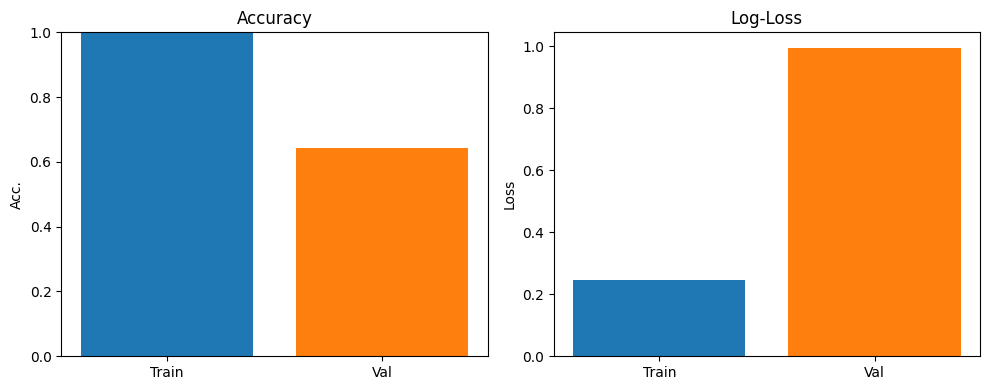


Classification report:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       101
           1       0.58      0.61      0.59        99
           2       0.72      0.55      0.63        94
           3       0.75      0.91      0.82        89
           4       0.72      0.64      0.68        83

    accuracy                           0.67       466
   macro avg       0.68      0.68      0.67       466
weighted avg       0.68      0.67      0.67       466

Precision: 0.6755
Recall   : 0.6738
F1 score : 0.6703


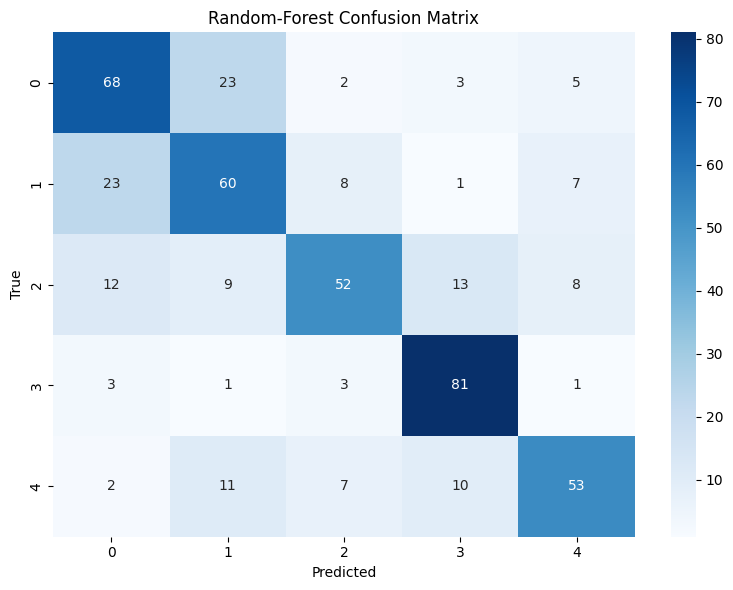

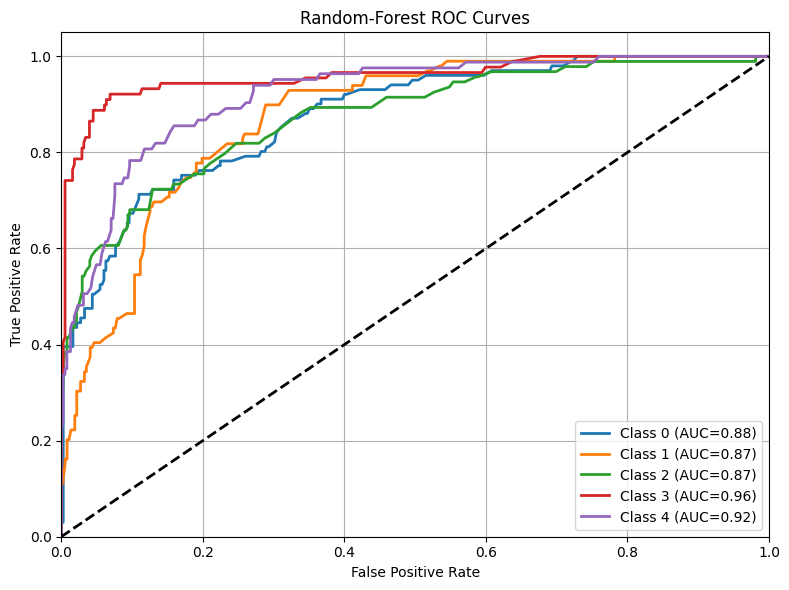

In [ ]:
"""
Random-Forest baseline for 5-class knee-X-ray classification
Now with accuracy / loss curves and ROC curves.
"""

# ───────────────────── Imports ─────────────────────
import os, cv2, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             log_loss, roc_curve, auc)

# ─────────── 1. Paths & hyper-params (unchanged) ───────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE     = (128, 128)
N_CLASSES    = len(os.listdir(TRAIN_DIR))
RF_ESTIMATORS = 400
RF_MAX_DEPTH  = None
RF_SEED       = 42

# ─────────── 2. BPHE preprocessing (unchanged) ────────────
def bphe_rgb(img):
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    ycrcb      = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb  = cv2.split(ycrcb)
    y_eq       = cv2.equalizeHist(y)
    img_eq_rgb = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return img_eq_rgb.astype(np.float32) / 127.5 - 1.0

# ─────────── 3. Image-loader (unchanged) ───────────
def load_images(root):
    X, y = [], []
    for cls in sorted(os.listdir(root)):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in tqdm(os.listdir(cls_path), desc=f'Loading {cls}'):
            img = cv2.imread(os.path.join(cls_path, fname))
            if img is None:          # corrupted
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
            img = bphe_rgb(img)
            X.append(img.flatten())
            y.append(cls)
    return np.stack(X, 0), y

print('Reading data …')
X_train, y_train = load_images(TRAIN_DIR)
X_val,   y_val   = load_images(VAL_DIR)
X_test,  y_test  = load_images(TEST_DIR)

# ─────────── 4. Label-encode ───────────
le           = LabelEncoder()
y_train_enc  = le.fit_transform(y_train)
y_val_enc    = le.transform(y_val)
y_test_enc   = le.transform(y_test)
class_labels = le.classes_.tolist()

# ─────────── 5. Train RF ───────────
rf = RandomForestClassifier(
        n_estimators=RF_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        n_jobs=-1,
        random_state=RF_SEED,
        class_weight='balanced')
print('\nTraining Random-Forest …')
rf.fit(X_train, y_train_enc)

# ─────────── 6. Accuracy & log-loss (train vs val) ───────────
train_acc  = rf.score(X_train, y_train_enc)
val_acc    = rf.score(X_val,   y_val_enc)
train_loss = log_loss(y_train_enc, rf.predict_proba(X_train))
val_loss   = log_loss(y_val_enc,   rf.predict_proba(X_val))

# Bar “curves”
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(['Train', 'Val'], [train_acc, val_acc], color=['tab:blue','tab:orange'])
plt.ylim(0,1);   plt.title('Accuracy'); plt.ylabel('Acc.')

plt.subplot(1,2,2)
plt.bar(['Train', 'Val'], [train_loss, val_loss], color=['tab:blue','tab:orange'])
plt.title('Log-Loss');      plt.ylabel('Loss')
plt.tight_layout(); plt.show()

# ─────────── 7. Test evaluation ───────────
y_pred      = rf.predict(X_test)
y_proba     = rf.predict_proba(X_test)
conf_mat    = confusion_matrix(y_test_enc, y_pred)

print('\nClassification report:')
print(classification_report(y_test_enc, y_pred, target_names=class_labels))
print(f'Precision: {precision_score(y_test_enc, y_pred, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test_enc, y_pred, average="weighted"):.4f}')
print(f'F1 score : {f1_score(y_test_enc, y_pred, average="weighted"):.4f}')

# Confusion matrix heat-map
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Random-Forest Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# ─────────── 8. ROC (one-vs-rest) ───────────
from itertools import cycle
from sklearn.metrics import roc_curve, auc
y_test_bin = label_binarize(y_test_enc, classes=np.arange(N_CLASSES))

fpr, tpr, roc_auc = {}, {}, {}
colors = cycle(['tab:blue','tab:orange','tab:green','tab:red','tab:purple'])

plt.figure(figsize=(8,6))
for i, color in zip(range(N_CLASSES), colors):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {class_labels[i]} (AUC={roc_auc[i]:.2f})')

plt.plot([0,1],[0,1],'k--',lw=2)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Random-Forest ROC Curves')
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout(); plt.show()


In [6]:
#XGBOOST
!pip install xgboost
import xgboost
print(xgboost.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 73.2 MB/s eta 0:00:0000:0100:01
3.0.2


Reading data …


Loading 4: 100%|██████████| 83/83 [00:00<00:00, 150.74it/s]


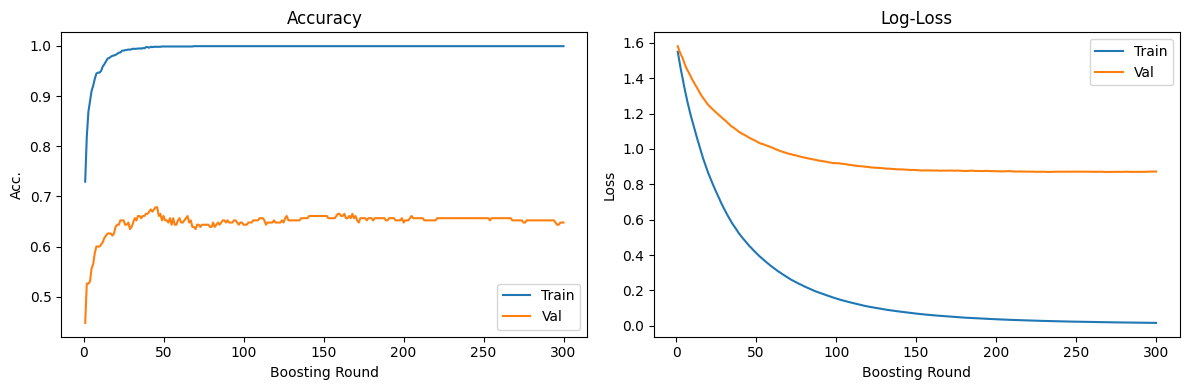

Final Val Accuracy: 0.6478

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.70      0.65       101
           1       0.56      0.59      0.57        99
           2       0.72      0.53      0.61        94
           3       0.78      0.89      0.83        89
           4       0.70      0.64      0.67        83

    accuracy                           0.67       466
   macro avg       0.67      0.67      0.67       466
weighted avg       0.67      0.67      0.66       466

Precision: 0.6709
Recall   : 0.6674
F1 score : 0.6645


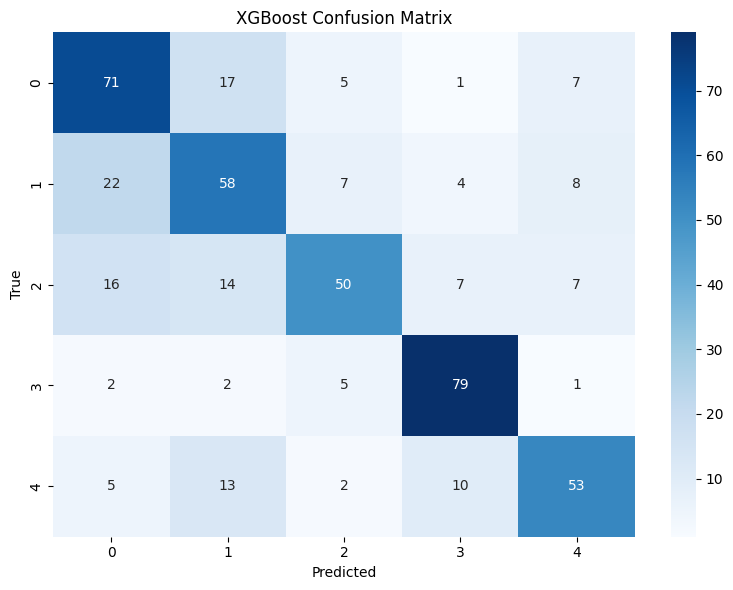

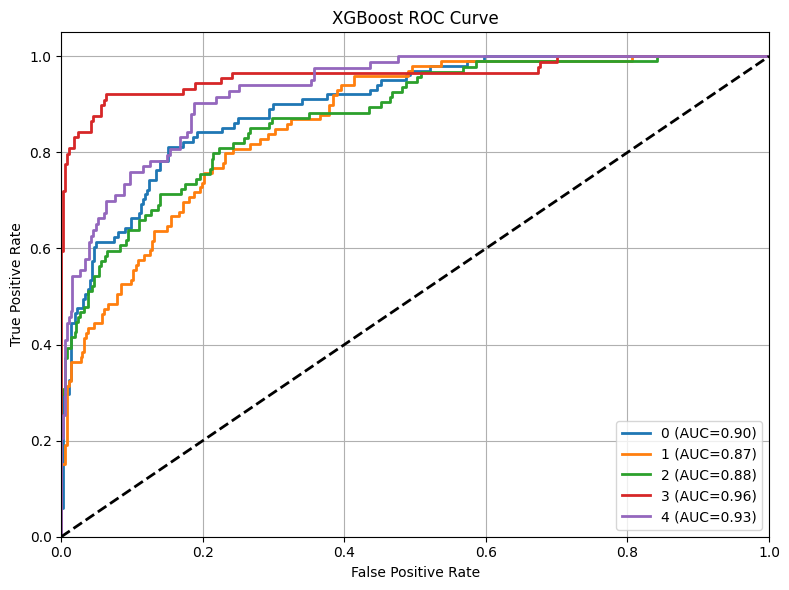

In [ ]:
"""
XGBoost baseline + curves for 5-class knee-X-ray classification
Folder layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ───────────────────── 1. IMPORTS ─────────────────────
import os, cv2, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)
from xgboost import XGBClassifier

# ───────────── 2. GLOBAL CONFIG ─────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE  = (128, 128)
N_CLASSES = len(os.listdir(TRAIN_DIR))

XGB_PARAMS = dict(
    objective     = 'multi:softprob',
    num_class     = N_CLASSES,
    n_estimators  = 300,
    learning_rate = 0.05,
    max_depth     = 6,
    subsample     = 0.8,
    colsample_bytree = 0.9,
    eval_metric   = ['mlogloss', 'merror'],   # track both loss & error
    tree_method   = 'hist',                  # 'gpu_hist' if CUDA present
    random_state  = 42
)

# ───────────── 3. BPHE PREPROCESS ─────────────
def bphe_rgb(img):
    img = img.astype(np.uint8) if img.max() > 1.0 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return img_eq.astype(np.float32) / 127.5 - 1.0

# ───────────── 4. DATA LOADER ─────────────
def load_dataset(root):
    X, y = [], []
    for cls in sorted(os.listdir(root)):
        cdir = os.path.join(root, cls)
        if not os.path.isdir(cdir): continue
        for f in tqdm(os.listdir(cdir), desc=f'Loading {cls}'):
            img = cv2.imread(os.path.join(cdir, f))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
            X.append(bphe_rgb(img).flatten())
            y.append(cls)
    return np.stack(X,0), y

print('Reading data …')
X_train, y_train = load_dataset(TRAIN_DIR)
X_val,   y_val   = load_dataset(VAL_DIR)
X_test,  y_test  = load_dataset(TEST_DIR)

# ───────────── 5. LABEL ENCODE ─────────────
le           = LabelEncoder()
y_train_enc  = le.fit_transform(y_train)
y_val_enc    = le.transform(y_val)
y_test_enc   = le.transform(y_test)
class_names  = le.classes_.tolist()

# ── optional scaling (helps when #features large) ──
scaler  = StandardScaler(with_mean=False)
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ───────────── 6. TRAIN XGBoost ─────────────
xgb_clf = XGBClassifier(**XGB_PARAMS)

xgb_clf.fit(
    X_train, y_train_enc,
    eval_set=[(X_train, y_train_enc), (X_val, y_val_enc)],
    verbose=False               # silence built-in logger
)

ev = xgb_clf.evals_result()     # history dict

# ───────────── 7. ACCURACY & LOSS CURVES ─────────────
epochs = range(1, len(ev['validation_0']['mlogloss'])+1)
train_loss = ev['validation_0']['mlogloss']
val_loss   = ev['validation_1']['mlogloss']
train_acc  = [1 - e for e in ev['validation_0']['merror']]
val_acc    = [1 - e for e in ev['validation_1']['merror']]

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_acc, label='Train')
plt.plot(epochs, val_acc, label='Val')
plt.title('Accuracy'); plt.xlabel('Boosting Round'); plt.ylabel('Acc.'); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, label='Train')
plt.plot(epochs, val_loss, label='Val')
plt.title('Log-Loss'); plt.xlabel('Boosting Round'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Final Val Accuracy: {val_acc[-1]:.4f}')

# ───────────── 8. TEST EVALUATION ─────────────
y_pred_enc = xgb_clf.predict(X_test)
conf_mat   = confusion_matrix(y_test_enc, y_pred_enc)

print('\nClassification Report:')
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))
print(f'Precision: {precision_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')
print(f'F1 score : {f1_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')

# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('XGBoost Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# ───────────── 9. ROC CURVE ─────────────
y_proba    = xgb_clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test_enc, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8,6))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_names[i]} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--',lw=2)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve'); plt.legend(loc='lower right'); plt.grid(True)
plt.tight_layout(); plt.show()


In [8]:
#CATEGORICAL BOOST
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 76.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]


Reading training …


Loading 4: 100%|██████████| 288/288 [00:01<00:00, 263.98it/s]


Reading validation …


Loading 4: 100%|██████████| 41/41 [00:00<00:00, 264.66it/s]


Reading test …


Loading 4: 100%|██████████| 83/83 [00:00<00:00, 251.92it/s]



Training CatBoost …
0:	learn: 1.5946725	test: 1.5970289	best: 1.5970289 (0)	total: 3.41s	remaining: 16m 59s
50:	learn: 1.1280428	test: 1.3275060	best: 1.3275060 (50)	total: 2m 54s	remaining: 14m 9s
100:	learn: 0.8624643	test: 1.2097940	best: 1.2097940 (100)	total: 5m 45s	remaining: 11m 20s
150:	learn: 0.6835710	test: 1.1335965	best: 1.1335965 (150)	total: 8m 34s	remaining: 8m 28s
200:	learn: 0.5500606	test: 1.0722396	best: 1.0722396 (200)	total: 11m 24s	remaining: 5m 37s
250:	learn: 0.4499696	test: 1.0260015	best: 1.0260015 (250)	total: 14m 16s	remaining: 2m 47s
299:	learn: 0.3809956	test: 0.9983102	best: 0.9983102 (299)	total: 17m 4s	remaining: 0us

bestTest = 0.9983102101
bestIteration = 299

Best iteration  : 299
Validation acc. : 0.6304


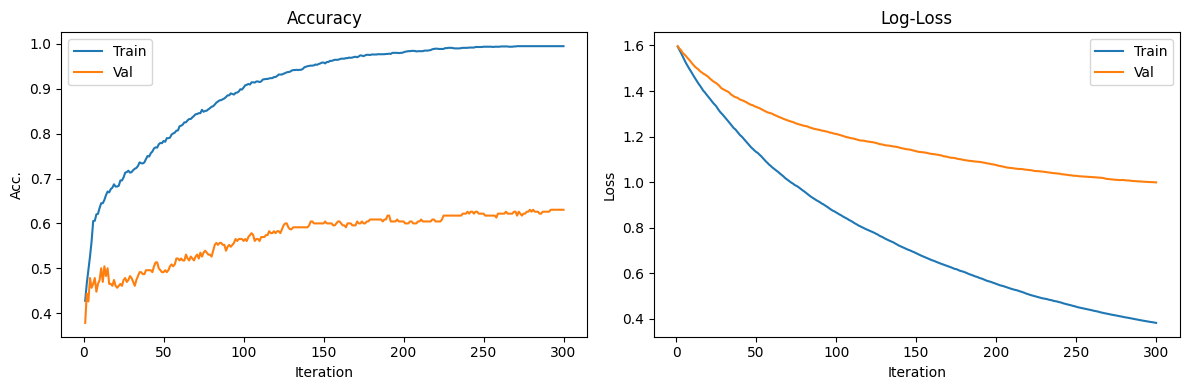


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       101
           1       0.61      0.61      0.61        99
           2       0.71      0.52      0.60        94
           3       0.77      0.89      0.83        89
           4       0.66      0.70      0.68        83

    accuracy                           0.67       466
   macro avg       0.68      0.68      0.67       466
weighted avg       0.67      0.67      0.67       466

Precision: 0.6738
Recall   : 0.6738
F1 score : 0.6699


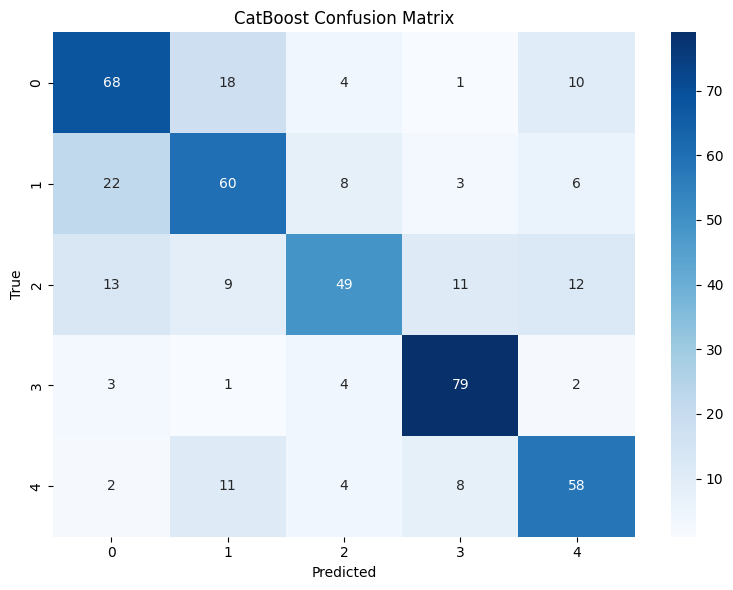

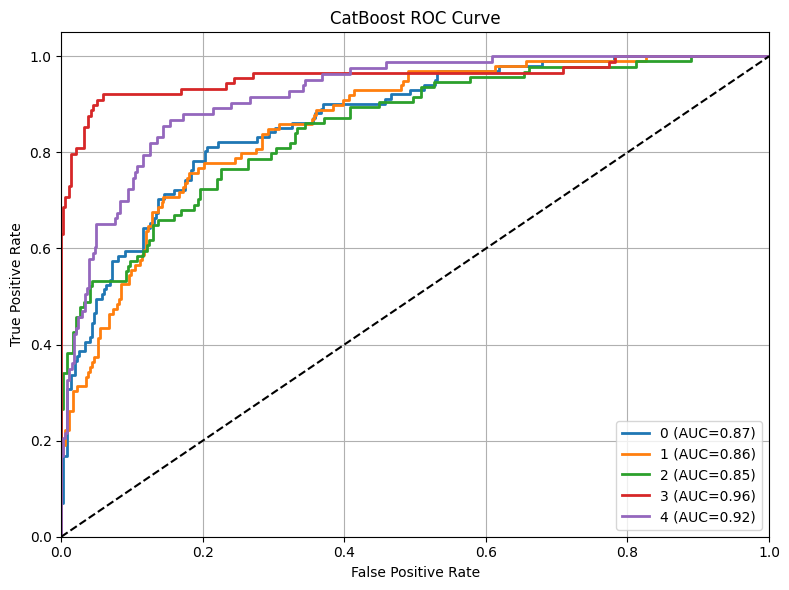

In [ ]:
"""
CatBoost baseline + curves for 5-class knee-X-ray classification
Folder layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────────── 1. IMPORTS ────────────────────────────
import os, cv2, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)
from catboost import CatBoostClassifier, Pool

# ───────────────────── 2. PATHS & CONSTANTS ────────────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE   = (128, 128)
N_CLASSES  = len(os.listdir(TRAIN_DIR))

CB_PARAMS = dict(
    iterations     = 300,
    learning_rate  = 0.05,
    depth          = 8,
    loss_function  = 'MultiClass',
    eval_metric    = 'MultiClass',
    custom_metric=['Accuracy'],
    l2_leaf_reg    = 3,
    border_count   = 128,
    random_seed    = 42,
    od_type        = 'Iter',
    od_wait        = 30,
    verbose        = 50,
    task_type      = 'CPU'      # change to 'CPU' if GPU not available
)

# ───────────────────── 3. PREPROCESSING ────────────────────────────
def bphe_rgb(img):
    img  = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return img_eq.astype(np.float32) / 127.5 - 1.0

# ───────────────────── 4. LOAD DATA ────────────────────────────────
def load_dataset(root):
    X, y = [], []
    for cls in sorted(os.listdir(root)):
        cdir = os.path.join(root, cls)
        if not os.path.isdir(cdir): continue
        for f in tqdm(os.listdir(cdir), desc=f'Loading {cls}'):
            img = cv2.imread(os.path.join(cdir, f))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
            X.append(bphe_rgb(img).flatten())
            y.append(cls)
    return np.stack(X, 0), y

print("Reading training …"); X_train, y_train = load_dataset(TRAIN_DIR)
print("Reading validation …"); X_val, y_val   = load_dataset(VAL_DIR)
print("Reading test …");      X_test, y_test  = load_dataset(TEST_DIR)

# ───────────────────── 5. LABEL ENCODE ─────────────────────────────
le           = LabelEncoder()
y_train_enc  = le.fit_transform(y_train)
y_val_enc    = le.transform(y_val)
y_test_enc   = le.transform(y_test)
class_names  = le.classes_.tolist()

train_pool = Pool(X_train, y_train_enc)
val_pool   = Pool(X_val,   y_val_enc)

# ───────────────────── 6. TRAIN CATBOOST ──────────────────────────
print("\nTraining CatBoost …")
cb_clf = CatBoostClassifier(**CB_PARAMS)
cb_clf.fit(train_pool,
           eval_set=val_pool)

evals = cb_clf.get_evals_result()       # history dict
best_iter = cb_clf.get_best_iteration()
print(f"Best iteration  : {best_iter}")
print(f"Validation acc. : {cb_clf.score(X_val, y_val_enc):.4f}")

# ──────── 7. ACCURACY & LOSS CURVES (per iteration) ───────────────
train_loss = evals['learn']['MultiClass']
val_loss   = evals['validation']['MultiClass']
train_acc  = evals['learn']['Accuracy']
val_acc    = evals['validation']['Accuracy']
iters      = range(1, len(train_loss)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(iters, train_acc, label='Train'); plt.plot(iters, val_acc, label='Val')
plt.title('Accuracy'); plt.xlabel('Iteration'); plt.ylabel('Acc.'); plt.legend()
plt.subplot(1,2,2); plt.plot(iters, train_loss, label='Train'); plt.plot(iters, val_loss, label='Val')
plt.title('Log-Loss'); plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ───────────────────── 8. TEST EVALUATION ─────────────────────────
y_pred_enc = cb_clf.predict(X_test).astype(int).flatten()
conf_mat   = confusion_matrix(y_test_enc, y_pred_enc)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))
print(f'Precision: {precision_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')
print(f'F1 score : {f1_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CatBoost Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# ───────────────────── 9. ROC CURVE ───────────────────────────────
y_prob     = cb_clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test_enc, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8,6))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for i,c in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=c, lw=2,
             label=f'{class_names[i]} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--',lw=1.5)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('CatBoost ROC Curve'); plt.legend(loc='lower right'); plt.grid(True)
plt.tight_layout(); plt.show()


In [ ]:
#SUPPORT VECTOR MACHINE

Reading training …


Loading 4: 100%|██████████| 288/288 [00:01<00:00, 251.81it/s]


Reading validation …


Loading 4: 100%|██████████| 41/41 [00:00<00:00, 253.23it/s]


Reading test …


Loading 4: 100%|██████████| 83/83 [00:00<00:00, 275.91it/s]



Training CatBoost …
0:	learn: 1.5946725	test: 1.5970289	best: 1.5970289 (0)	total: 3.38s	remaining: 16m 50s
50:	learn: 1.1280428	test: 1.3275060	best: 1.3275060 (50)	total: 2m 56s	remaining: 14m 20s
100:	learn: 0.8624643	test: 1.2097940	best: 1.2097940 (100)	total: 5m 50s	remaining: 11m 29s
150:	learn: 0.6835710	test: 1.1335965	best: 1.1335965 (150)	total: 8m 41s	remaining: 8m 35s
200:	learn: 0.5500606	test: 1.0722396	best: 1.0722396 (200)	total: 11m 33s	remaining: 5m 41s
250:	learn: 0.4499696	test: 1.0260015	best: 1.0260015 (250)	total: 14m 25s	remaining: 2m 49s
299:	learn: 0.3809956	test: 0.9983102	best: 0.9983102 (299)	total: 17m 14s	remaining: 0us

bestTest = 0.9983102101
bestIteration = 299

Best iteration  : 299
Validation acc. : 0.6304


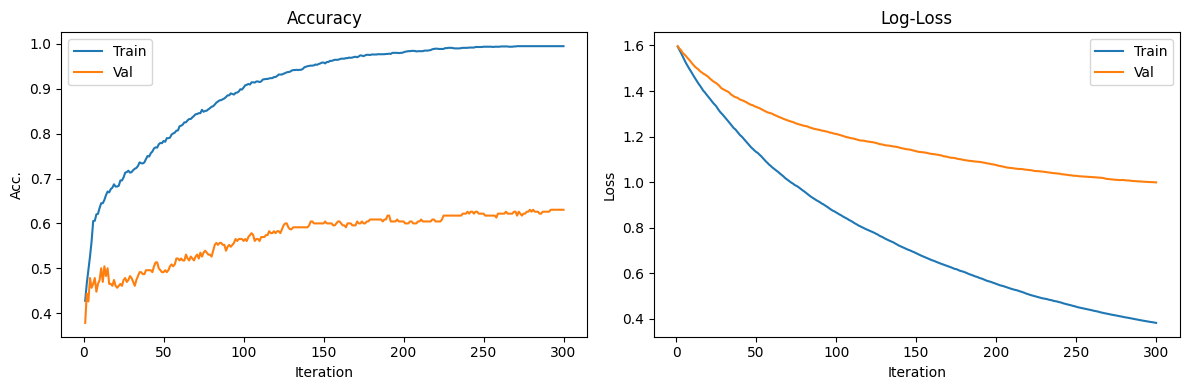


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.67      0.65       101
           1       0.61      0.61      0.61        99
           2       0.71      0.52      0.60        94
           3       0.77      0.89      0.83        89
           4       0.66      0.70      0.68        83

    accuracy                           0.67       466
   macro avg       0.68      0.68      0.67       466
weighted avg       0.67      0.67      0.67       466

Precision: 0.6738
Recall   : 0.6738
F1 score : 0.6699


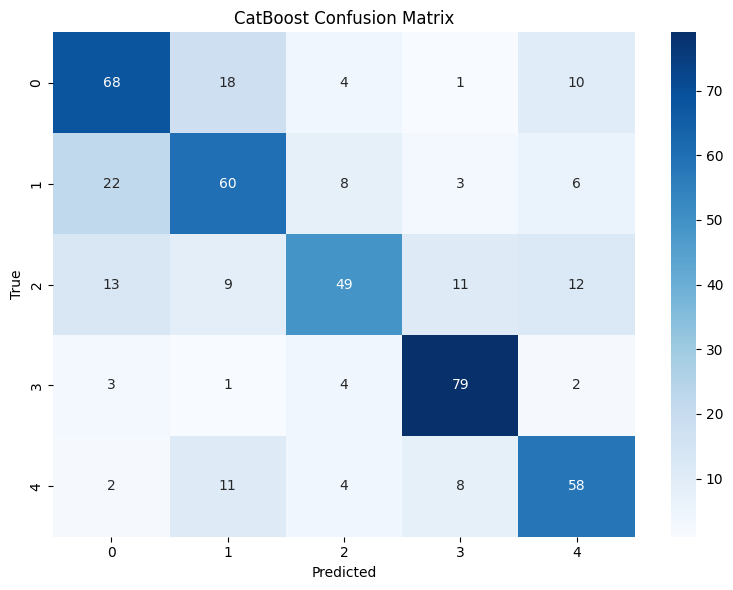

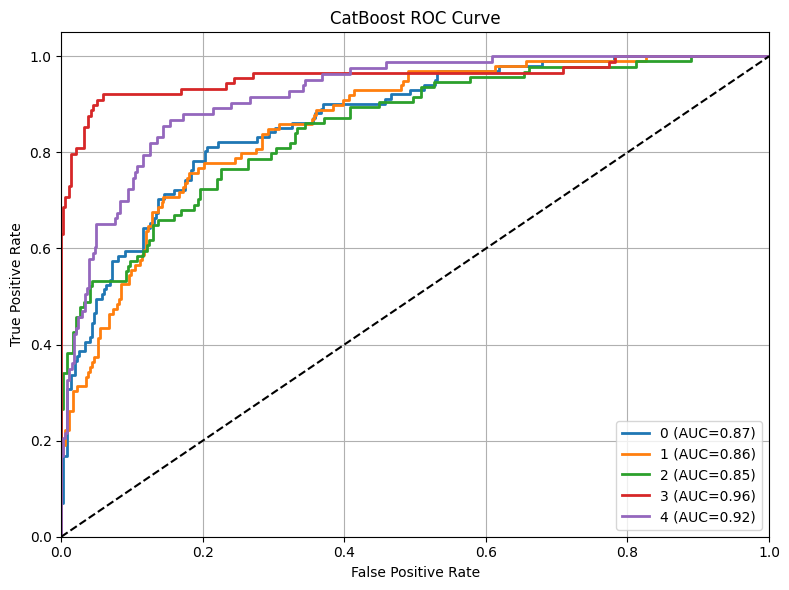

Reading training set …


Loading 4: 100%|██████████| 288/288 [00:01<00:00, 265.61it/s]


Reading validation set …


Loading 4: 100%|██████████| 41/41 [00:00<00:00, 271.02it/s]


Reading test set …


Loading 4: 100%|██████████| 83/83 [00:00<00:00, 266.34it/s]



Training SVM …


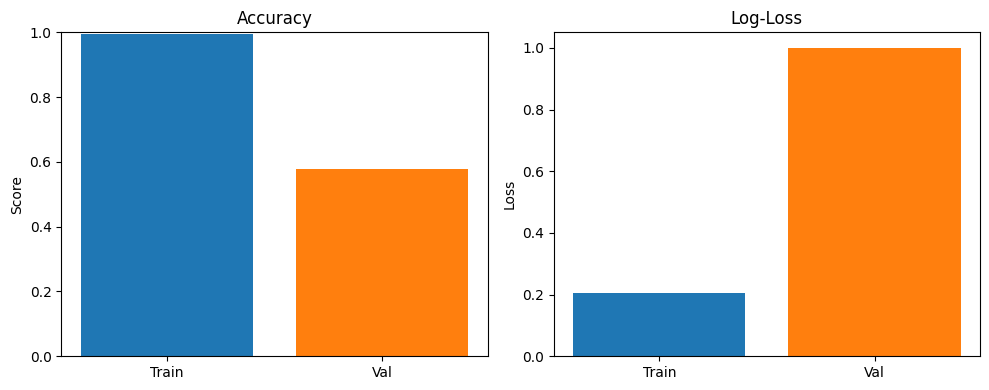


Classification report:
              precision    recall  f1-score   support

           0       0.59      0.75      0.66       101
           1       0.54      0.56      0.55        99
           2       0.71      0.51      0.59        94
           3       0.84      0.89      0.86        89
           4       0.64      0.57      0.60        83

    accuracy                           0.65       466
   macro avg       0.66      0.65      0.65       466
weighted avg       0.66      0.65      0.65       466

Precision: 0.6594
Recall:    0.6545
F1 score:  0.6512


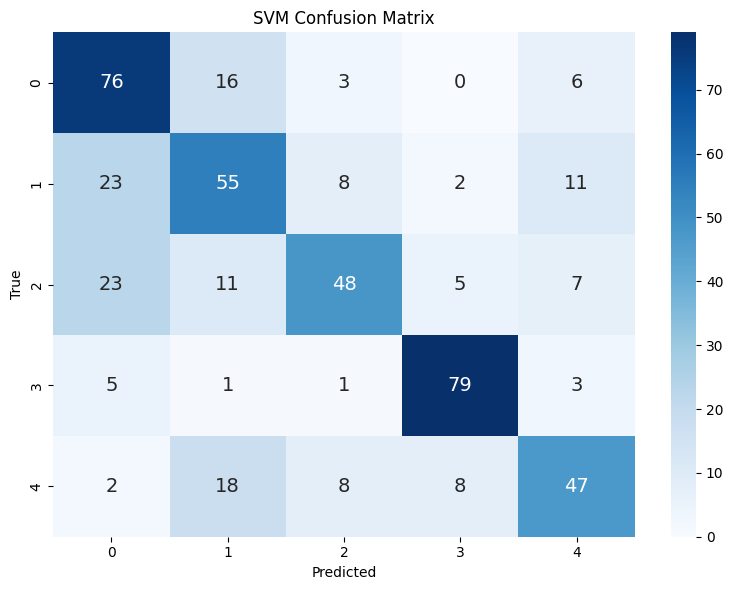

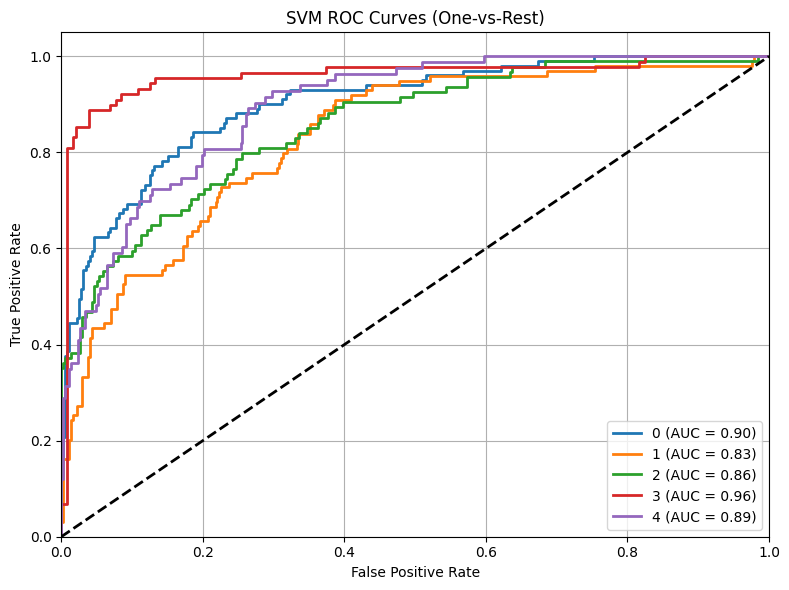

In [ ]:
"""
Support-Vector-Machine (SVM) baseline for 5-class knee-X-ray classification,
now with accuracy/loss bars and multi-class ROC curves.

Assumes folder structure:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.(png|jpg)
"""

# ────────────────────────────── 1. Imports ────────────────────────────────────
import os, cv2, numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    log_loss, roc_curve, auc
)
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

# ───────────────────────── 2. Global configuration ───────────────────────────
"""
CatBoost baseline + curves for 5-class knee-X-ray classification
Folder layout:
E:/FA011/MSC/SplittedDataset/{train|val|test}/<class_name>/*.png|*.jpg
"""

# ─────────────────────────── 1. IMPORTS ────────────────────────────
import os, cv2, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)
from catboost import CatBoostClassifier, Pool

# ───────────────────── 2. PATHS & CONSTANTS ────────────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE   = (128, 128)
N_CLASSES  = len(os.listdir(TRAIN_DIR))

CB_PARAMS = dict(
    iterations     = 300,
    learning_rate  = 0.05,
    depth          = 8,
    loss_function  = 'MultiClass',
    eval_metric    = 'MultiClass',
    custom_metric=['Accuracy'],
    l2_leaf_reg    = 3,
    border_count   = 128,
    random_seed    = 42,
    od_type        = 'Iter',
    od_wait        = 30,
    verbose        = 50,
    task_type      = 'CPU'      # change to 'CPU' if GPU not available
)

# ───────────────────── 3. PREPROCESSING ────────────────────────────
def bphe_rgb(img):
    img  = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return img_eq.astype(np.float32) / 127.5 - 1.0

# ───────────────────── 4. LOAD DATA ────────────────────────────────
def load_dataset(root):
    X, y = [], []
    for cls in sorted(os.listdir(root)):
        cdir = os.path.join(root, cls)
        if not os.path.isdir(cdir): continue
        for f in tqdm(os.listdir(cdir), desc=f'Loading {cls}'):
            img = cv2.imread(os.path.join(cdir, f))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
            X.append(bphe_rgb(img).flatten())
            y.append(cls)
    return np.stack(X, 0), y

print("Reading training …"); X_train, y_train = load_dataset(TRAIN_DIR)
print("Reading validation …"); X_val, y_val   = load_dataset(VAL_DIR)
print("Reading test …");      X_test, y_test  = load_dataset(TEST_DIR)

# ───────────────────── 5. LABEL ENCODE ─────────────────────────────
le           = LabelEncoder()
y_train_enc  = le.fit_transform(y_train)
y_val_enc    = le.transform(y_val)
y_test_enc   = le.transform(y_test)
class_names  = le.classes_.tolist()

train_pool = Pool(X_train, y_train_enc)
val_pool   = Pool(X_val,   y_val_enc)

# ───────────────────── 6. TRAIN CATBOOST ──────────────────────────
print("\nTraining CatBoost …")
cb_clf = CatBoostClassifier(**CB_PARAMS)
cb_clf.fit(train_pool,
           eval_set=val_pool)

evals = cb_clf.get_evals_result()       # history dict
best_iter = cb_clf.get_best_iteration()
print(f"Best iteration  : {best_iter}")
print(f"Validation acc. : {cb_clf.score(X_val, y_val_enc):.4f}")

# ──────── 7. ACCURACY & LOSS CURVES (per iteration) ───────────────
train_loss = evals['learn']['MultiClass']
val_loss   = evals['validation']['MultiClass']
train_acc  = evals['learn']['Accuracy']
val_acc    = evals['validation']['Accuracy']
iters      = range(1, len(train_loss)+1)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(iters, train_acc, label='Train'); plt.plot(iters, val_acc, label='Val')
plt.title('Accuracy'); plt.xlabel('Iteration'); plt.ylabel('Acc.'); plt.legend()
plt.subplot(1,2,2); plt.plot(iters, train_loss, label='Train'); plt.plot(iters, val_loss, label='Val')
plt.title('Log-Loss'); plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ───────────────────── 8. TEST EVALUATION ─────────────────────────
y_pred_enc = cb_clf.predict(X_test).astype(int).flatten()
conf_mat   = confusion_matrix(y_test_enc, y_pred_enc)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))
print(f'Precision: {precision_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')
print(f'Recall   : {recall_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')
print(f'F1 score : {f1_score(y_test_enc, y_pred_enc, average="weighted"):.4f}')

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('CatBoost Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# ───────────────────── 9. ROC CURVE ───────────────────────────────
y_prob     = cb_clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test_enc, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8,6))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for i,c in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=c, lw=2,
             label=f'{class_names[i]} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--',lw=1.5)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('CatBoost ROC Curve'); plt.legend(loc='lower right'); plt.grid(True)
plt.tight_layout(); plt.show()

IMG_SIZE       = (128, 128)
N_CLASSES      = len(os.listdir(TRAIN_DIR))
PCA_COMPONENTS = 300

# Enable probabilities for ROC
SVM_PARAMS = dict(
    C           = 10.0,
    kernel      = 'rbf',
    gamma       = 'scale',
    probability = True        # <— needed for predict_proba
)

# ───────────────────────── 3. BPHE preprocessing ─────────────────────────────
def bphe_rgb(img):
    """Histogram-equalise luminance channel; output float32 in [-1,1]."""
    img = img.astype(np.uint8) if img.max() > 1.0 else (img * 255).astype(np.uint8)
    ycrcb      = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb  = cv2.split(ycrcb)
    y_eq       = cv2.equalizeHist(y)
    img_eq_rgb = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return img_eq_rgb.astype(np.float32) / 127.5 - 1.0

# ───────────────────────── 4. Dataset loader ─────────────────────────────────
def load_dataset(root_dir):
    X, y = [], []
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for fname in tqdm(os.listdir(cls_path), desc=f'Loading {cls}'):
            img = cv2.imread(os.path.join(cls_path, fname))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
            img = bphe_rgb(img)
            X.append(img.flatten())
            y.append(cls)
    return np.stack(X, axis=0), y

print("Reading training set …")
X_train, y_train = load_dataset(TRAIN_DIR)
print("Reading validation set …")
X_val,   y_val   = load_dataset(VAL_DIR)
print("Reading test set …")
X_test,  y_test  = load_dataset(TEST_DIR)

# ─────────────────────────── 5. Label encoding ───────────────────────────────
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
class_names = le.classes_.tolist()

# ───────────────────── 6. Feature scaling + PCA + SVM ────────────────────────
clf = make_pipeline(
    StandardScaler(with_mean=False),
    PCA(n_components=PCA_COMPONENTS, svd_solver='randomized', whiten=True),
    SVC(**SVM_PARAMS)
)

print("\nTraining SVM …")
clf.fit(X_train, y_train_enc)

# ────────────────── 7. Accuracy & Loss (Train vs Val) ───────────────────────
train_acc  = clf.score(X_train, y_train_enc)
val_acc    = clf.score(X_val,   y_val_enc)
train_loss = log_loss(y_train_enc, clf.predict_proba(X_train))
val_loss   = log_loss(y_val_enc,   clf.predict_proba(X_val))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(['Train', 'Val'], [train_acc, val_acc], color=['tab:blue','tab:orange'])
plt.ylim(0,1)
plt.title('Accuracy')
plt.ylabel('Score')

plt.subplot(1,2,2)
plt.bar(['Train', 'Val'], [train_loss, val_loss], color=['tab:blue','tab:orange'])
plt.title('Log-Loss')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

# ───────────────────────────── 8. Evaluation ────────────────────────────────
y_pred = clf.predict(X_test)
conf_mat = confusion_matrix(y_test_enc, y_pred)

print("\nClassification report:")
print(classification_report(y_test_enc, y_pred, target_names=class_names))
print(f"Precision: {precision_score(y_test_enc, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test_enc, y_pred, average='weighted'):.4f}")
print(f"F1 score:  {f1_score(y_test_enc, y_pred, average='weighted'):.4f}")

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size':14})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

# ───────────────────────────── 9. ROC Curves ────────────────────────────────
y_proba = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test_enc, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8,6))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for i, color in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', lw=2)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#NAIVE BAYES

Loading data…


Loading 4: 100%|██████████| 83/83 [00:00<00:00, 276.49it/s]



Training GaussianNB…


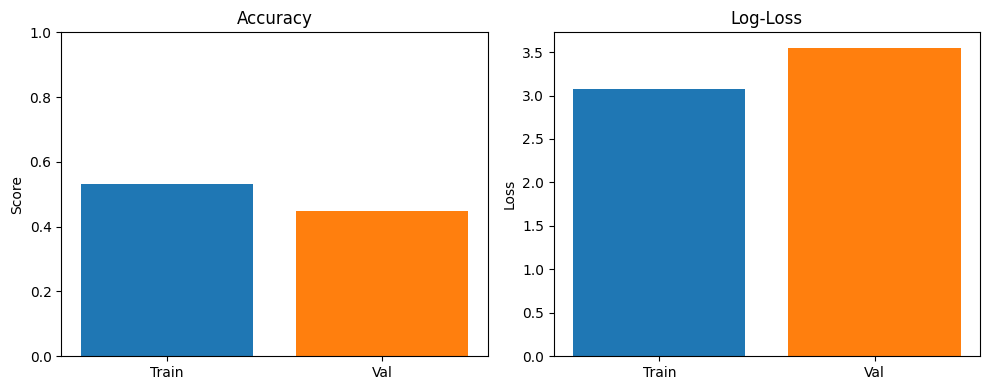


Train Acc: 0.5310, Val Acc: 0.4478
Train Loss: 3.0742, Val Loss: 3.5496

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.71      0.46       101
           1       0.39      0.22      0.28        99
           2       0.52      0.30      0.38        94
           3       0.70      0.64      0.67        89
           4       0.49      0.35      0.41        83

    accuracy                           0.45       466
   macro avg       0.49      0.44      0.44       466
weighted avg       0.48      0.45      0.44       466

Precision: 0.4809
Recall   : 0.4464
F1 Score : 0.4355


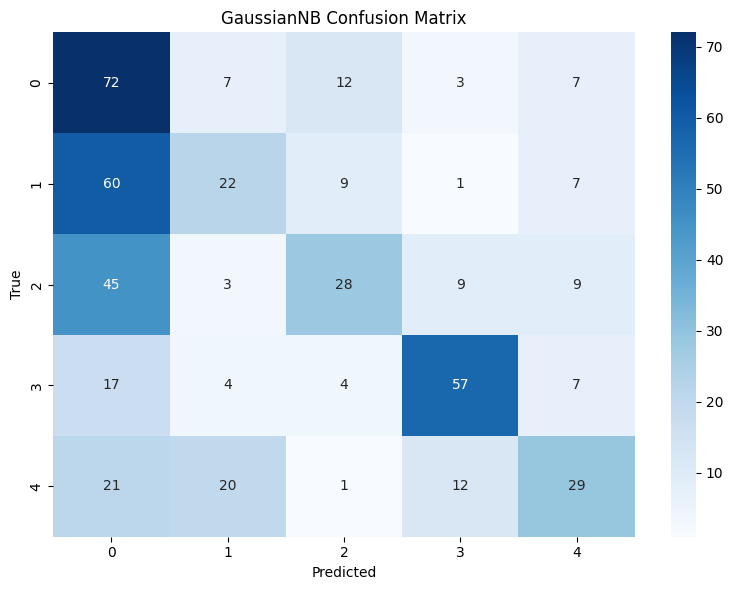

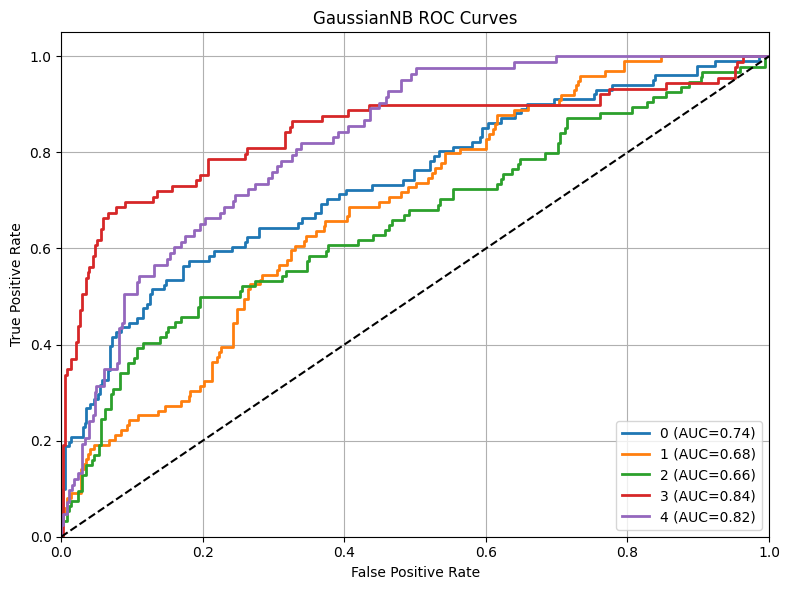

In [ ]:
"""
Gaussian Naive Bayes baseline + accuracy/loss & ROC curves
for 5-class knee-X-ray classification.
"""

# ─────────────────────── 1. IMPORTS ───────────────────────
import os, cv2, numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    log_loss, roc_curve, auc
)

# ────────────────────── 2. PATHS & SETTINGS ──────────────────────
TRAIN_DIR = '/mnt/d/FA019/new/SplittedDataset/train'
VAL_DIR   ='/mnt/d/FA019/new/SplittedDataset/val'
TEST_DIR  = '/mnt/d/FA019/new/SplittedDataset/test'

IMG_SIZE       = (96, 96)
PCA_COMPONENTS = 200

# ─────────────────────── 3. PREPROCESSING ───────────────────────
def bphe_rgb(img):
    img = img.astype(np.uint8) if img.max() > 1 else (img * 255).astype(np.uint8)
    y, cr, cb = cv2.split(cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb))
    y_eq = cv2.equalizeHist(y)
    img_eq = cv2.cvtColor(cv2.merge((y_eq, cr, cb)), cv2.COLOR_YCrCb2RGB)
    return img_eq.astype(np.float32) / 255.0

# ─────────────────────── 4. DATA LOADER ───────────────────────
def load_dataset(root_dir):
    X, y = [], []
    for cls in sorted(os.listdir(root_dir)):
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path): continue
        for fname in tqdm(os.listdir(cls_path), desc=f'Loading {cls}'):
            img = cv2.imread(os.path.join(cls_path, fname))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
            X.append(bphe_rgb(img).flatten())
            y.append(cls)
    return np.stack(X, axis=0), y

print("Loading data…")
X_train, y_train = load_dataset(TRAIN_DIR)
X_val,   y_val   = load_dataset(VAL_DIR)
X_test,  y_test  = load_dataset(TEST_DIR)

# ────────────────────── 5. LABEL ENCODING ──────────────────────
le           = LabelEncoder()
y_train_enc  = le.fit_transform(y_train)
y_val_enc    = le.transform(y_val)
y_test_enc   = le.transform(y_test)
class_names  = le.classes_.tolist()
n_classes    = len(class_names)

# ──────────── 6. SCALE → PCA → GAUSSIAN NB ────────────
scaler = StandardScaler(with_mean=False)
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

pca = PCA(n_components=PCA_COMPONENTS, svd_solver='randomized', whiten=False)
X_train_p = pca.fit_transform(X_train_s)
X_val_p   = pca.transform(X_val_s)
X_test_p  = pca.transform(X_test_s)

gnb = GaussianNB()

print("\nTraining GaussianNB…")
gnb.fit(X_train_p, y_train_enc)

# ───────────── 7. ACCURACY & LOG-LOSS ─────────────
train_acc  = gnb.score(X_train_p, y_train_enc)
val_acc    = gnb.score(X_val_p,   y_val_enc)
train_loss = log_loss(y_train_enc, gnb.predict_proba(X_train_p))
val_loss   = log_loss(y_val_enc,   gnb.predict_proba(X_val_p))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.bar(['Train','Val'], [train_acc, val_acc], color=['tab:blue','tab:orange'])
plt.ylim(0,1); plt.title('Accuracy'); plt.ylabel('Score')

plt.subplot(1,2,2)
plt.bar(['Train','Val'], [train_loss, val_loss], color=['tab:blue','tab:orange'])
plt.title('Log-Loss'); plt.ylabel('Loss')
plt.tight_layout(); plt.show()

print(f"\nTrain Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")
print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# ────────────── 8. TEST EVALUATION ──────────────
y_pred = gnb.predict(X_test_p)
conf_mat = confusion_matrix(y_test_enc, y_pred)

print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred, target_names=class_names))
print(f"Precision: {precision_score(y_test_enc, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test_enc, y_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test_enc, y_pred, average='weighted'):.4f}")

plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('GaussianNB Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# ────────────── 9. ROC CURVE ──────────────
y_proba = gnb.predict_proba(X_test_p)
y_test_bin = label_binarize(y_test_enc, classes=np.arange(n_classes))

plt.figure(figsize=(8,6))
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
for i, c in enumerate(colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=c, lw=2,
             label=f'{class_names[i]} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1.5)
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.title('GaussianNB ROC Curves')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(loc='lower right'); plt.grid(True); plt.tight_layout(); plt.show()
